In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
# Graph visualization code adopted from Andrej Karpathy's micrograd lecture jupyternotebook:
# https://github.com/karpathy/nn-zero-to-hero/tree/master/lectures/micrograd

# NOTE: graphviz is a python wrapper on top of graphviz's dot binary which needs to be installed on your machine.
# I used brew install graphviz for this.

from graphviz import Digraph


def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()

    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges


def draw_dot(root):
    dot = Digraph(format="svg", graph_attr={"rankdir": "LR"})  # LR = left to right

    nodes, edges = trace(root)

    # create all the nodes in the graph -- records and ops
    # add all op->record edges in the graph
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(
            name=uid,
            label="{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad),
            shape="record",
        )
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name=uid + n._op, label=n._op)
            # and connect the op node to it
            dot.edge(uid + n._op, uid)

    # add all the record->op edges in the graph
    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot


In [21]:
class Value:
    def __init__(self, data, predecessors=(), label="", op=""):
        self.data = data
        self.label = label  # object label for viz
        self._op = op  # operation that created the object
        self._prev = predecessors  # who created the object using the operation
        self.grad = 0
        self._backward = lambda: None  # function

    # __repr__ --> object or print(object) both work
    # __str__ --> only print(object) works
    def __repr__(self):
        return f"Value({self.data})"

    # called when "+" is used. Eg: obj1 + obj2
    def __add__(self, other):
        # wrap right operand in Value class to allow for cases like obj1 + integer
        other = other if isinstance(other, Value) else Value(other)

        # forward pass
        out = Value(self.data + other.data, predecessors=(self, other), op="+")

        # back propagation -- propagate gradients to out's predecessors
        # chain rule -- dL/dself = dL/dout * dout/dself = out.grad * dout/dself
        def _backward():
            self.grad += out.grad
            other.grad += out.grad

        out._backward = _backward

        return out

    # called when "*" is used. Eg: obj1 * obj2
    def __mul__(self, other):
        # allows for cases where user passes obj1 * integer
        other = other if isinstance(other, Value) else Value(other)

        # forward pass
        out = Value(self.data * other.data, predecessors=(self, other), op="*")

        # back propagation
        def _backward():
            self.grad += out.grad * other.data
            other.grad += out.grad * self.data

        out._backward = _backward

        return out

    # called when "**" is used. Eg: obj1 ** integer
    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supports integer or float power"

        # forward pass
        out = Value(self.data**other, predecessors=(self,), op=f"**{other}")

        # back propagation
        def _backward():
            self.grad += out.grad * (other * self.data ** (other - 1))

        out._backward = _backward

        return out

    # tanh method direct and complete implementation
    # formula: (e^2x - 1)/(e^2x + 1)
    def tanh(self):
        # forward pass
        x = math.exp(2 * self.data)
        t = (x - 1) / (x + 1)
        out = Value(t, predecessors=(self,), op="tanh")

        # back propagation
        def _backward():
            self.grad += out.grad * (1 - (t**2))

        out._backward = _backward

        return out

    # no dunder for exponent
    def exp(self):
        # forward pass
        t = math.exp(self.data)
        out = Value(t, predecessors=(self,), op="exp")

        def _backward():
            self.grad += out.grad * t

        out._backward = _backward

        return out

    # called when "/" is used. Eg: obj1/obj2
    # makes use of the __pow__ and __mul__ methods
    # we could've taken the standard route of self.data/other.data, but reusing * and ** saves us time
    def __truediv__(self, other):
        return self * other**-1

    # called when "-" is used. Eg: obj1 - obj2
    # makes use of the __add__ and __mul__ methods
    def __sub__(self, other):
        return self + other * -1

    # reflected multiplication
    # (2 * obj) first tries 2.__mul__(obj) and fails because we don't wrap left operand in Value class.
    # 2.__mul__(obj) fails --> obj.__rmul__(2) as fallback --> obj.__mul__(2) gets called --> 2 gets wrapped as Value(2)
    def __rmul__(self, other):
        return self * other

    # reflected addition
    def __radd__(self, other):  # other + self
        return self + other


In [32]:
a = Value(2)
a.label = "a"
b = Value(3)
b.label = "b"
c = a + b
c.label = "c"
d = Value(4)
d.label = "d"
e = c * d
e.label = "e"
f = e**2
f.label = "f"
g = Value(50)
g.label = "g"
h = f / g
h.label = "h"
i = Value(1)
i.label = "i"
j = h + i
j.label = "j"


# # # compute tanh(j) --> (e^2j - 1)/(e^2j + 1)
# # # method 1: directly implementing tanh computation in the value class
# # L = j.tanh()
# # L.label = "L"

# method 2: implementing tanh computation using component methods in the value class
j_exp = (2 * j).exp()  # case for __rmul__
L = (j_exp - 1) / (j_exp + 1)
L.label = "L"


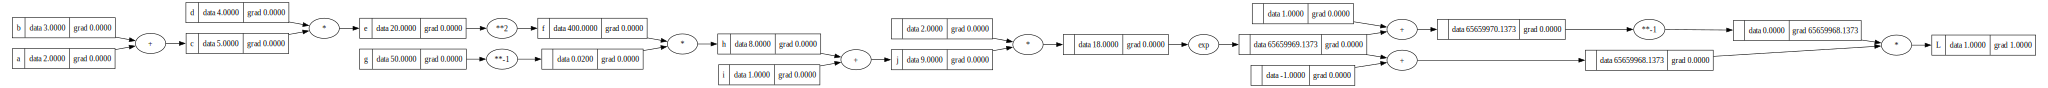

In [35]:
draw_dot(L)

In [34]:
L.grad = 1
L._backward()

In [30]:
# Single neuron forward pass
# Inputs
x1 = Value(2.0, label="x1")
x2 = Value(3.0, label="x2")

# Weights
w1 = Value(-1.5, label="w1")
w2 = Value(1.0, label="w2")

# Bias
b = Value(0.5, label="b")

# Forward pass: tanh(x1*w1 + x2*w2 + b)
n = x1 * w1 + x2 * w2 + b
n.label = "n"
out = n.tanh()
out.label = "out"

print(f"neuron data: {n.data:.4f}")
print(f"out (tanh)  : {out.data:.4f}")


neuron data: 0.5000
out (tanh)  : 0.4621


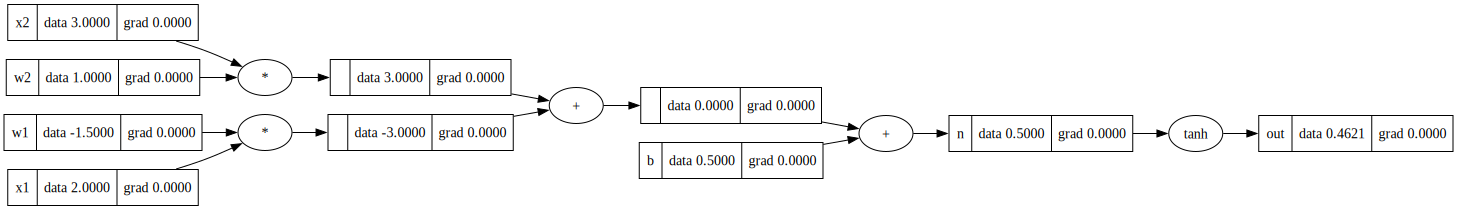

In [31]:
draw_dot(out)

In [ ]:
out.grad = 1
out._backward()
n._backward()


0